<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Lectures/CNN%20Lab%20with%20Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Lab with Keras

## **Table of Contents**

1. [Preliminaries & Setup](#section0)  
2. [Introduction & Key Concepts](#section1)  
   - 2.1 [Neural Network Fundamentals](#section1_1)  
   - 2.2 [Manual Convolution Filter Demonstration](#section1_2)  
   - 2.3 [Why CNNs vs. Dense Networks?](#section1_3)  
   - 2.4 [Mini-Quiz #1](#section1_4)  
3. [Part I: MNIST — Dense vs. CNN](#section2)  
   - 3.1 [Overview & Loading MNIST](#section2_1)  
   - 3.2 [Build & Train a Dense Network (Baseline)](#section2_2)  
   - 3.3 [Build & Train a CNN on MNIST](#section2_3)  
   - 3.4 [Visualizing CNN Filters & Activations](#section2_4)  
   - 3.5 [Try-It-Yourself (TIY)](#section2_5)  
   - 3.6 [Mini-Quiz #2](#section2_6)  
4. [Part II: CIFAR-10 — Data Augmentation](#section3)  
   - 4.1 [Loading & Exploring CIFAR-10](#section3_1)  
   - 4.1.1 [Data Augmentation Demonstration](#section3_1_1)  
   - 4.2 [CNN with Data Augmentation](#section3_2)  
   - 4.3 [Try-It-Yourself (TIY)](#section3_3)  
   - 4.4 [Mini-Quiz #3](#section3_4)  
5. [Part III: Transfer Learning (Cats vs. Dogs)](#section4)  
   - 5.1 [Why Transfer Learning?](#section4_1)  
   - 5.2 [Loading Cats vs. Dogs from TFDS](#section4_2)  
   - 5.3 [Feature Extraction & Fine-Tuning](#section4_3)  
   - 5.4 [Try-It-Yourself (TIY)](#section4_4)  
   - 5.5 [Mini-Quiz #4](#section4_5)  
6. [Optional: TensorBoard Demonstration](#section5)  
7. [Optional: Grad-CAM Demonstration](#section6)  
8. [Hyperparameter Tuning Tips](#section7)  
9. [Reflection & Summary](#section8)  
10. [Additional Best Practices](#section9)  
11. [Common Pitfalls & Solutions](#section10)  
12. [Wrap-Up & Further Resources](#section11)


<a name="section0"></a>
## **1. Preliminaries & Setup**

**For Google Colab**:
1. **Open** [Colab](https://colab.research.google.com).  
2. **Set GPU**: Runtime → Change runtime type → Hardware accelerator = GPU.  
3. **Install** packages:

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

!pip install tensorflow-datasets --quiet
print("TensorFlow version:", tf.__version__)

device_list = tf.config.list_physical_devices('GPU')
print("GPUs Available:", device_list)

TensorFlow version: 2.18.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<a name="section1"></a>
## **2. Introduction & Key Concepts**

<a name="section1_1"></a>
### 2.1 Neural Network Fundamentals
- **Neuron**: Computes $ \sigma(\mathbf{w} \cdot \mathbf{x} + b) $.  
- **Layers**: Dense, Convolutional, Pooling, etc.  
- **Forward & Backprop**: Predictions compare to ground truth to compute loss → update weights.

<a name="section1_2"></a>
### 2.2 Manual Convolution Filter Demonstration

**Show** how edge detection or blur works via a **manual** convolution of an image.  

Original shape: (512, 512)


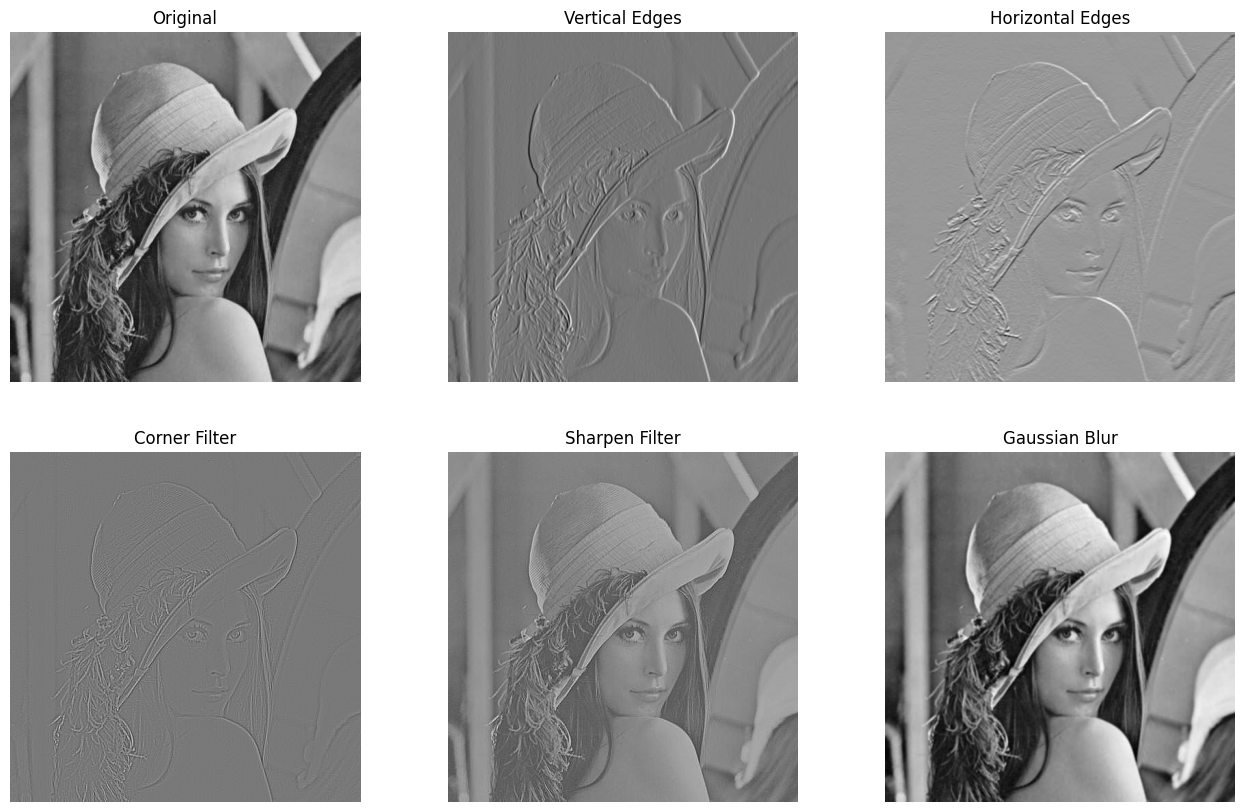

In [19]:
import requests, os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Download a sample grayscale image (Lena)
url = "https://boofcv.org/images/f/fe/Original_lena512.jpg"
img_path = "lena.jpg"
if not os.path.exists(img_path):
    r = requests.get(url)
    with open(img_path, "wb") as f:
        f.write(r.content)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
print("Original shape:", img.shape)

# Define filters
vertical_filter = np.array([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1]
], dtype=np.float32)

horizontal_filter = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

corner_filter = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

# NEW: Sharpen filter
sharpen_filter = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# NEW: Gaussian blur filter
gaussian_filter = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32)/16.0

# Convolve
vertical_edges   = convolve2d(img, vertical_filter,  mode='same', boundary='symm')
horizontal_edges = convolve2d(img, horizontal_filter,mode='same', boundary='symm')
corner_response  = convolve2d(img, corner_filter,    mode='same', boundary='symm')
sharpened_img    = convolve2d(img, sharpen_filter,   mode='same', boundary='symm')
blurred_img      = convolve2d(img, gaussian_filter,  mode='same', boundary='symm')

# Plot results
fig, axs = plt.subplots(2, 3, figsize=(16,10))
axs[0,0].imshow(img, cmap='gray')
axs[0,0].set_title("Original"); axs[0,0].axis('off')

axs[0,1].imshow(vertical_edges, cmap='gray')
axs[0,1].set_title("Vertical Edges"); axs[0,1].axis('off')

axs[0,2].imshow(horizontal_edges, cmap='gray')
axs[0,2].set_title("Horizontal Edges"); axs[0,2].axis('off')

axs[1,0].imshow(corner_response, cmap='gray')
axs[1,0].set_title("Corner Filter"); axs[1,0].axis('off')

axs[1,1].imshow(sharpened_img, cmap='gray')
axs[1,1].set_title("Sharpen Filter"); axs[1,1].axis('off')

axs[1,2].imshow(blurred_img, cmap='gray')
axs[1,2].set_title("Gaussian Blur"); axs[1,2].axis('off')

plt.show()


Each output image corresponds to your original grayscale Lena image passed through a different 3×3 filter—so they each highlight or alter features in different ways:

1. **Vertical Edges**  
   - This filter responds strongly where there’s a **vertical intensity gradient**—i.e., columns in the image that change from dark to light or vice versa.  
   - Hence you see the outline of Lena’s hat, face, and background edges emphasized primarily where vertical transitions occur.

2. **Horizontal Edges**  
   - Similarly, this filter picks up **horizontal gradients**, so horizontal edges of the hat brim, shoulders, or background lines become most visible.  
   - Vertical transitions are largely ignored, making vertical edges appear less bright.

3. **Corner Filter** (Laplacian‐like kernel)  
   - This kernel is sensitive to **rapid intensity changes** in all directions—often including corners or small point‐like features.  
   - You’ll see an outline of Lena’s entire face and hat, but also more faint lines or corners that might not show up as strongly in the simple vertical/horizontal filters.

4. **Sharpen Filter**  
   - Emphasizes edges and local contrast by adding a portion of the pixel’s difference from its neighbors back to the pixel itself.  
   - So the overall image remains recognizable but with more pronounced edges/contrast—almost like an “unsharp mask” effect from classic image editing.

5. **Gaussian Blur**  
   - Smooths out local variations by taking a weighted average of each pixel’s neighbors, effectively **reducing noise and fine detail**.  
   - The result is a softer, blurred version of the original image, with edges and details less distinct.

### **Interpretation**

- **Edge Detectors (vertical/horizontal)**: Show you where the image has strong intensity gradients in specific directions.  
- **Corner/Laplacian**: Highlights points or areas where intensity changes sharply in all directions (often called corners).  
- **Sharpen**: Increases local contrast, making details pop more.  
- **Gaussian Blur**: Smooths or softens the image by averaging pixels in a Gaussian‐weighted neighborhood.

Together, these filters illustrate several common operations in image processing, each revealing or modifying different aspects of the same Lena image.

<a name="section1_3"></a>
### 2.3 Why CNNs vs. Dense Networks?

- **Dense**: Flatten images, ignoring local spatial structure, leading to a large parameter count.  
- **CNN**: Applies shared filters across the image, capturing edges & shapes more effectively with fewer parameters.

<a name="section1_4"></a>
### 2.4 Mini-Quiz #1

1. *Which operation do we use to detect edges in an image?*  
   A) **Convolution**  
   B) Fully connected layers  
   C) Batch normalization  

2. *True or False?* Convolution filters in a CNN are *hand-crafted* like in classical image processing.  
   **Answer**: False—CNN filters are *learned* during training.

<a name="section2"></a>
## **3. Part I: MNIST — Dense vs. CNN**

<a name="section2_1"></a>
### 3.1 Overview & Loading MNIST


In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32')/255.0
x_test  = x_test.astype('float32') /255.0

val_size = 5000
x_val = x_train[:val_size]
y_val = y_train[:val_size]
x_train = x_train[val_size:]
y_train = y_train[val_size:]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


<a name="section2_2"></a>
### 3.2 Build & Train a Dense Network (Baseline)

In [5]:
x_train_flat = x_train.reshape(-1, 784)
x_val_flat   = x_val.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

model_dense = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_dense.fit(
    x_train_flat, y_train,
    epochs=5, batch_size=64,
    validation_data=(x_val_flat, y_val)
)

test_loss_dense, test_acc_dense = model_dense.evaluate(x_test_flat, y_test)
print("Dense Network Test Accuracy:", test_acc_dense)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8529 - loss: 0.5099 - val_accuracy: 0.9602 - val_loss: 0.1434
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9634 - loss: 0.1221 - val_accuracy: 0.9706 - val_loss: 0.0997
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9733 - loss: 0.0860 - val_accuracy: 0.9708 - val_loss: 0.0976
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9826 - loss: 0.0569 - val_accuracy: 0.9746 - val_loss: 0.0878
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9861 - loss: 0.0428 - val_accuracy: 0.9778 - val_loss: 0.0764
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0912
Dense Network Test Accuracy: 0.9769999980926514


<a name="section2_3"></a>
### 3.3 Build & Train a CNN on MNIST

In [8]:
# Expand dims
x_train_cnn = x_train[..., np.newaxis]
x_val_cnn   = x_val[...,   np.newaxis]
x_test_cnn  = x_test[...,  np.newaxis]

# 2. Define & Compile Model (Functional API)
input_layer = tf.keras.layers.Input(shape=(28,28,1))
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(input_layer)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
output_layer = tf.keras.layers.Dense(10, activation='softmax')(x)

model_cnn = tf.keras.Model(inputs=input_layer, outputs=output_layer)
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Train
model_cnn.fit(x_train_cnn, y_train, epochs=5, batch_size=64, validation_data=(x_val_cnn, y_val))

# 4. Evaluate on Test
test_loss, test_acc = model_cnn.evaluate(x_test_cnn, y_test)
print("Test Accuracy:", test_acc)


Epoch 1/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8748 - loss: 0.4167 - val_accuracy: 0.9814 - val_loss: 0.0631
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9808 - loss: 0.0616 - val_accuracy: 0.9870 - val_loss: 0.0466
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9883 - loss: 0.0401 - val_accuracy: 0.9878 - val_loss: 0.0438
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9907 - loss: 0.0286 - val_accuracy: 0.9880 - val_loss: 0.0375
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9929 - loss: 0.0219 - val_accuracy: 0.9900 - val_loss: 0.0377
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9871 - loss: 0.0402
Test Accuracy: 0.9896000027656555


<a name="section2_4"></a>
### 3.4 Visualizing CNN Filters & Activations

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


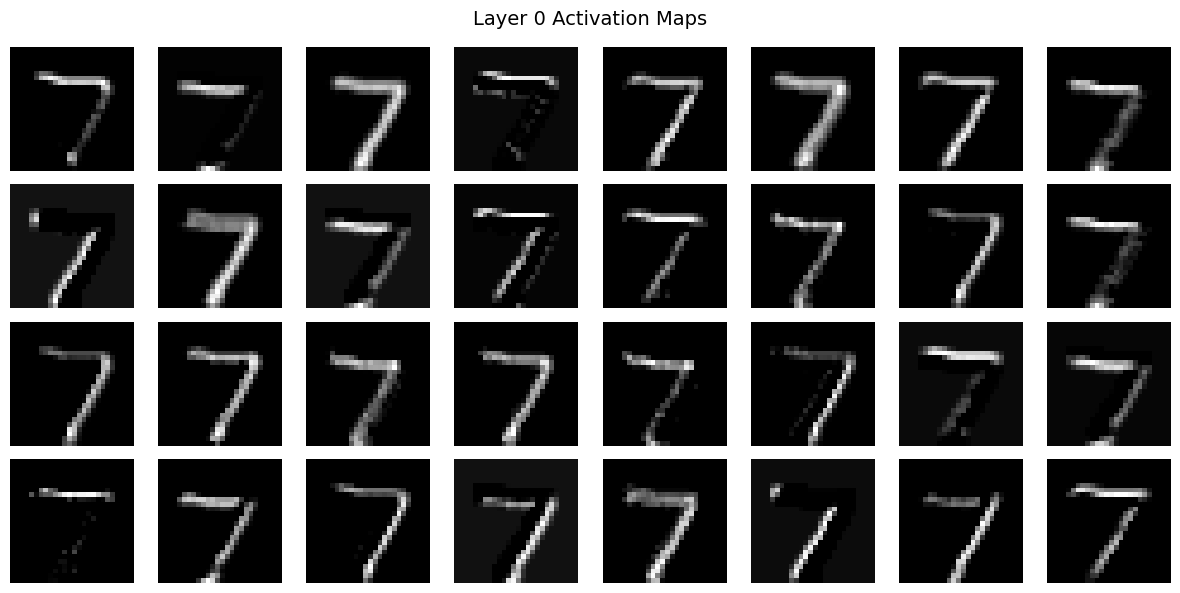

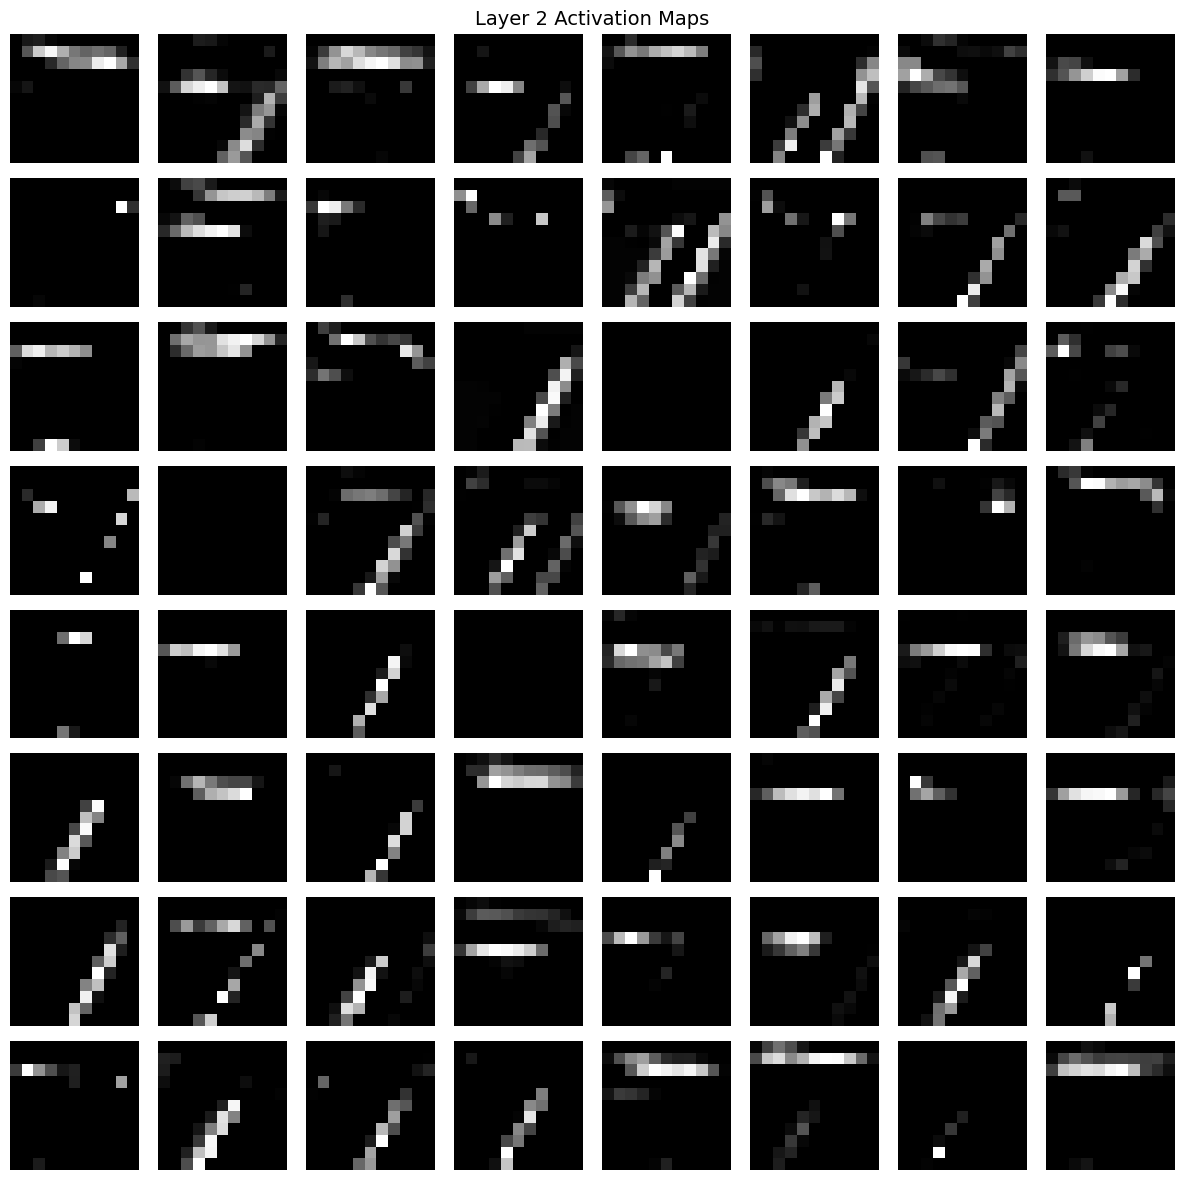

In [12]:
# 5. Force a forward pass (optional but safe)
_ = model_cnn.predict(x_train_cnn[:1])

# 6. Build Sub-Model
layer_outputs = [layer.output for layer in model_cnn.layers[1:6]]  # Skip Input layer
activation_model = tf.keras.Model(inputs=model_cnn.input, outputs=layer_outputs)

# 7. Check activations on a sample
sample_img = x_test_cnn[:1]
activations = activation_model.predict(sample_img)

# 8. Visualize Only activations[0] and activations[2] (first & second conv layers)
indices_to_show = [0, 2]  # the indexes in 'activations' that correspond to conv layers

for i in indices_to_show:
    layer_activation = activations[i]  # e.g., activations[0] or [2]
    # layer_activation shape -> (1, height, width, channels)

    num_channels = layer_activation.shape[-1]
    n_cols = 8
    n_rows = math.ceil(num_channels / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
    fig.suptitle(f"Layer {i} Activation Maps", fontsize=14)

    # If there's only 1 row, 'axes' might not be a 2D array
    axes = np.array(axes).reshape(n_rows, n_cols)

    for c in range(num_channels):
        row, col = divmod(c, n_cols)
        channel_img = layer_activation[0, :, :, c]
        axes[row, col].imshow(channel_img, cmap='gray')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


These grids are **activation maps** (feature maps) from the **first** and **second** convolutional layers of your CNN when it sees the digit “7.” Each small image in the grid corresponds to one filter (channel) in that conv layer, showing which parts of the “7” it responds to:

1. **Layer 0 (First Conv Layer)**  
   - You have 32 filters in this layer. Most filters still look a lot like the original digit (though slightly altered), because early filters typically learn to detect basic edges, corners, or strokes.  
   - Bright/white areas in a given sub-image mean that filter sees something it recognizes (like an edge or stroke) at those locations. Dark/black means little or no activation there.

2. **Layer 2 (Second Conv Layer)**  
   - This layer has more filters (64), and each filter tends to be **more specialized**—some respond strongly to diagonal strokes (the slash in “7”), others might pick up smaller corner shapes.  
   - You’ll notice these maps often look more “fragmented” or “abstract.” That’s expected: deeper filters combine or refine the features found by earlier filters, focusing on lines, angles, or partial shapes relevant to the digit.

3. **Why the Differences**  
   - **Early conv layers** (Layer 0) generally highlight simple edges or outlines.  
   - **Deeper conv layers** (Layer 2 here) look for more specific or refined patterns (like diagonals, corners, or intersections).

4. **Interpretation**  
   - A bright region in a feature map means “this filter sees a relevant feature here.”  
   - Some filters appear almost black—meaning they didn’t find that particular “feature” in the digit “7.”  
   - This is how CNNs progressively build up from generic edge detection (Layer 0) to more digit-specific details (Layer 2 and beyond).

**In short:** each small “activation map” shows where that learned filter “fires” for the “7.” The first layer still somewhat resembles the original image with edges highlighted, while the second layer is more abstract, emphasizing diagonal lines or parts of the digit that help the CNN identify it as a “7.”

<a name="section2_5"></a>
### 3.5 **Try-It-Yourself (TIY)**

Below are **code stubs** to guide your modifications:

**TIY #1: Changing Kernel Size**

In [ ]:
# === TIY #1: Insert Your Code Here ===
# Modify (3,3) to (5,5) in the first Conv2D below

model_cnn_tiy = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (# Insert Your Code Here ), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn_tiy.compile(...)
model_cnn_tiy.fit(...)

**TIY #2: Add/Remove a Conv Layer**

In [11]:
# === TIY #2: Insert Your Code Here ===
# You can add an extra Conv2D + MaxPooling2D block or remove one.
# Watch for overfitting or changes in accuracy & training time.

**TIY #3: Visualize Misclassifications**

In [12]:
# === TIY #3: Insert Your Code Here ===
# 1. preds = model_cnn.predict(x_test_cnn)
# 2. predicted_labels = np.argmax(preds, axis=1)
# 3. Compare with y_test, plot some misclassified digits.

<a name="section2_6"></a>
### 3.6 Mini-Quiz #2

1. *Why might a CNN outperform a dense network on MNIST?*  
   - **Answer**: Because convolution captures local pixel patterns with fewer parameters.

2. *Which layer typically follows a Conv2D layer to reduce spatial dimensions?*  
   - A) **MaxPooling2D**  
   - B) Dense  
   - C) Activation

<a name="section3"></a>
## **4. Part II: CIFAR-10 — Data Augmentation**

<a name="section3_1"></a>
### 4.1 Loading & Exploring CIFAR-10

In [14]:
(x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = tf.keras.datasets.cifar10.load_data()
x_train_c10 = x_train_c10.astype('float32') / 255.0
x_test_c10  = x_test_c10.astype('float32')  / 255.0

val_size = 5000
x_val_c10 = x_train_c10[:val_size]
y_val_c10 = y_train_c10[:val_size]
x_train_c10 = x_train_c10[val_size:]
y_train_c10 = y_train_c10[val_size:]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


**Classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

<a name="section3_1_1"></a>
### 4.1.1 **Data Augmentation Demonstration**

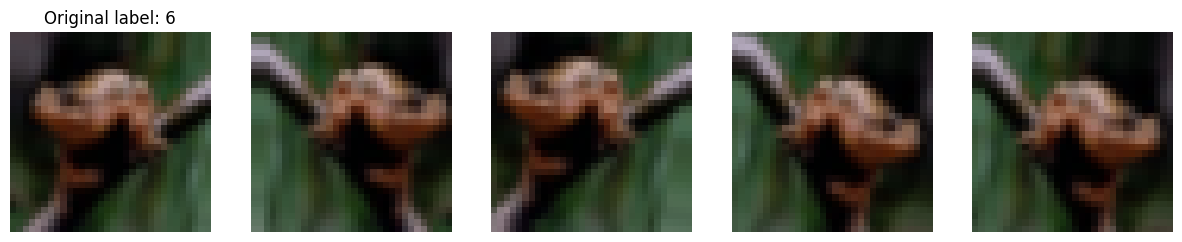

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

demo_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

sample_image_c10 = x_train_c10[0]
sample_label_c10 = y_train_c10[0]

demo_batch = np.expand_dims(sample_image_c10, axis=0)
demo_iter = demo_datagen.flow(demo_batch, batch_size=1)

fig, axs = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    aug_img = next(demo_iter)[0].astype('float32')
    axs[i].imshow(aug_img)
    axs[i].axis('off')
axs[0].set_title(f"Original label: {sample_label_c10[0]}")
plt.show()

<a name="section3_2"></a>
### 4.2 CNN with Data Augmentation

In [16]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator()

batch_size = 64
train_generator_c10 = train_datagen.flow(x_train_c10, y_train_c10, batch_size=batch_size)
val_generator_c10   = val_datagen.flow(x_val_c10, y_val_c10, batch_size=batch_size)

model_cifar = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cifar.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cifar = model_cifar.fit(
    train_generator_c10,
    steps_per_epoch=len(x_train_c10)//batch_size,
    epochs=10,
    validation_data=val_generator_c10,
    validation_steps=len(x_val_c10)//batch_size
)

test_loss_cifar, test_acc_cifar = model_cifar.evaluate(x_test_c10, y_test_c10, batch_size=batch_size)
print("CIFAR-10 Test Accuracy:", test_acc_cifar)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


703/703 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.2554 - loss: 2.0081 - val_accuracy: 0.4858 - val_loss: 1.4801
Epoch 2/10
  1/703 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5000 - loss: 1.6059

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.5000 - loss: 1.6059 - val_accuracy: 0.4778 - val_loss: 1.4890
Epoch 3/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.4164 - loss: 1.5910 - val_accuracy: 0.5022 - val_loss: 1.3752
Epoch 4/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.4375 - loss: 1.5999 - val_accuracy: 0.5016 - val_loss: 1.3910
Epoch 5/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.4673 - loss: 1.4713 - val_accuracy: 0.5206 - val_loss: 1.3034
Epoch 6/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.4688 - loss: 1.3986 - val_accuracy: 0.5347 - val_loss: 1.2780
Epoch 7/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.4985 - loss: 1.3899 - val_accuracy: 0.5781 - val_loss: 1.1751
Epoch 8/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.5312 - loss: 1.2033 - val_accuracy: 0.5871 - val_loss: 1.1546
Epoch 9/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5127 - loss: 1.3492 - val_accurac

<a name="section3_3"></a>
### 4.3 **Try-It-Yourself (TIY)**

**TIY #4: Adjust Augmentations**

In [ ]:
# === TIY #4: Insert Your Code Here ===
# 1. Add brightness_range, zoom_range, or shear_range to train_datagen
# 2. Re-train, observe changes in final accuracy

**TIY #5: Confusion Matrix**

In [ ]:
```python
# === TIY #5: Insert Your Code Here ===
# 1. preds = model_cifar.predict(x_test_c10)
# 2. predicted_classes = np.argmax(preds, axis=1)
# 3. true_classes = y_test_c10.flatten()
# 4. Use sklearn.metrics.confusion_matrix, plot a heatmap

<a name="section3_4"></a>
### 4.4 Mini-Quiz #3

1. *Which function in Keras helps us apply random flips, shifts, or rotations to images?*  
   - A) ImageDataGenerator  
   - B) data.DataLoader  
   - C) flow_from_directory  

2. *True or False?* Data augmentation can reduce overfitting by providing diverse training samples.  
   - **Answer**: True

<a name="section4"></a>
## **5. Part III: Transfer Learning (Cats vs. Dogs)**

<a name="section4_1"></a>
### 5.1 Why Transfer Learning?
- Use a **pretrained** CNN on ImageNet.  
- **Feature Extraction**: Freeze base layers.  
- **Fine-Tuning**: Unfreeze top layers to adapt them to your dataset.

<a name="section4_2"></a>
### 5.2 Loading Cats vs. Dogs from TFDS

In [26]:
import tensorflow_datasets as tfds

(ds_full, ds_info) = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)
ds_train = tfds.load('cats_vs_dogs', split='train[:80%]', as_supervised=True)
ds_val   = tfds.load('cats_vs_dogs', split='train[80%:90%]', as_supervised=True)
ds_test  = tfds.load('cats_vs_dogs', split='train[90%:]',   as_supervised=True)

def format_image(image, label):
    image = tf.image.resize(image, (224,224))
    image = image/255.0
    return image, label

batch_size = 32
ds_train = ds_train.map(format_image).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_val   = ds_val.map(format_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(format_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/23262 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.I217QM_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


<a name="section4_3"></a>
### 5.3 Feature Extraction & Fine-Tuning

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tl.fit(ds_train, epochs=5, validation_data=ds_val)

# Fine-tuning
for layer in base_model.layers[-4:]:
    layer.trainable = True

model_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model_tl.fit(ds_train, epochs=5, validation_data=ds_val)

test_loss, test_acc = model_tl.evaluate(ds_test)
print("Cats vs Dogs Test Accuracy:", test_acc)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 142s 216ms/step - accuracy: 0.8471 - loss: 0.4586 - val_accuracy: 0.9230 - val_loss: 0.1791
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 111s 186ms/step - accuracy: 0.9166 - loss: 0.2037 - val_accuracy: 0.9209 - val_loss: 0.1813
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 109s 185ms/step - accuracy: 0.9301 - loss: 0.1743 - val_accuracy: 0.9299 - val_loss: 0.1733
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 142s 186ms/step - accuracy: 0.9353 - loss: 0.1569 - val_accuracy: 0.9282 - val_loss: 0.1656
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 109s 185ms/step - accuracy: 0.9363 - loss: 0.1473 - val_accuracy: 0.9299 - val_loss: 0.1627
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 142s 230ms/step - accuracy: 0.9568 - loss: 0.1068 - val_accuracy: 0.9445 - val_loss: 0.1599
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 131s 223ms/step - accuracy: 0.9755 - loss: 0.0619 - val_accuracy: 0.9506 - val_loss: 0.1426
Epoch 3/5
582/582 ━━━━━━━━━━━━━━

<a name="section4_4"></a>
### 5.4 **Try-It-Yourself (TIY)**


**TIY #6: Freeze vs. Unfreeze**

In [ ]:
# === TIY #6: Insert Your Code Here ===
# 1. Freeze entire base -> train 3-5 epochs
# 2. Unfreeze last 4 layers -> smaller LR -> re-train
# 3. Compare final accuracy

**TIY #7: Change Pretrained Model**

In [ ]:
# === TIY #7: Insert Your Code Here ===
# from tensorflow.keras.applications import ResNet50 or MobileNetV2
# base_model_2 = ResNet50(...)
# Compare performance vs. VGG16

**TIY #8: Visualize Misclassifications**

In [ ]:
# === TIY #8: Insert Your Code Here ===
# 1. preds = model_tl.predict(ds_test)
# 2. threshold -> 0 or 1
# 3. gather true_labels, compare, plot misclassified cat/dog images

<a name="section4_5"></a>
### 5.5 Mini-Quiz #4

1. *When we unfreeze top layers in transfer learning, we should typically?*  
   - A) **Use a smaller learning rate**  
   - B) Use a bigger learning rate  
   - C) Use the same learning rate  

2. *True or False?* Feature extraction alone can’t achieve high accuracy.  
   - **Answer**: False—often it’s good enough, but fine-tuning can improve results further.

<a name="section5"></a>
## **6. Optional: TensorBoard Demonstration**

**Why**: Visualizing training/validation curves can help debug or monitor training progress.

In [ ]:
from tensorflow.keras.callbacks import TensorBoard
import datetime

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Example usage in model_cifar or model_cnn:
model_cnn.fit(
    x_train_cnn, y_train,
    epochs=5, batch_size=64,
    validation_data=(x_val_cnn, y_val),
    callbacks=[tensorboard_callback]
)

# In Colab:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit

<a name="section6"></a>
## **7. Optional: Grad-CAM Demonstration**

**Goal**: See *where* the CNN “looked” in an image.

In [ ]:
import numpy as np
import matplotlib.cm as cm
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap)+1e-8)
    return heatmap.numpy()

# Then overlay heatmap on original image, see which regions influenced the classification most.

<a name="section7"></a>
## **8. Hyperparameter Tuning Tips**

1. **Manual**: Try different batch sizes, learning rates, kernel sizes. Document results.  
2. **Keras Tuner**:  
   ```python
   # pip install keras-tuner
   # Example usage of a tuner with different hyperparameters.
   ```
3. **Observe** if bigger networks or more layers actually help or cause overfitting.

<a name="section8"></a>
## **9. Reflection & Summary**

**Students Learned**:
1. How **convolutions** detect edges and shapes (manual filter demo).  
2. **Dense vs. CNN** on MNIST, seeing CNN’s advantage.  
3. **Data Augmentation** on CIFAR-10 (demonstration + training).  
4. **Transfer Learning** for Cats vs. Dogs, with feature extraction & optional fine-tuning.  
5. **TensorBoard** for monitoring, **Grad-CAM** for interpretability, and **basic hyperparameter tuning** tips.

<a name="section9"></a>
## **10. Additional Best Practices**

- **Experiment Logging**: Keep a record (spreadsheet/MLflow) of changes & results.  
- **Early Stopping**: If validation loss stops improving, halt training.  
- **Data Splits**: Always maintain a separate test set to avoid data leakage.


<a name="section10"></a>
## **11. Common Pitfalls & Solutions**

1. **Overfitting**: More augmentation, dropout, or smaller architecture.  
2. **Shape Errors**: Always confirm `(batch, height, width, channels)`.  
3. **Learning Rate**: If stuck, lower or raise LR, or try a scheduler.  
4. **Data Leakage**: Strictly separate train/val/test.

<a name="section11"></a>
## **12. Wrap-Up & Further Resources**

**Congratulations**:  
- You’ve completed a **full journey**: from *manual convolution* to *CNN training* on MNIST/CIFAR-10, then *transfer learning* for Cats vs. Dogs.  
- **Try** adding more advanced augmentation (RandAugment, AutoAugment), or **Grad-CAM** for model interpretability.  
- Tinker with **hyperparameter tuning** for even better results.

### **Further Resources**

1. [Keras Documentation](https://keras.io/)  
2. [TensorFlow Tutorials](https://www.tensorflow.org/tutorials)  
3. [Stanford CS231n](http://cs231n.stanford.edu/)  
4. [Andrew Ng’s Deep Learning Specialization](https://www.coursera.org/specializations/deep-learning)